In [2]:
import pandas as pd

# Load PTB-XL metadata
df = pd.read_csv("C:\LEARNING\MINOR_2\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\ptbxl_database.csv")

print("Dataset shape:", df.shape)
df.head()

<>:4: SyntaxWarning: invalid escape sequence '\L'
<>:4: SyntaxWarning: invalid escape sequence '\L'
C:\Users\tbind\AppData\Local\Temp\ipykernel_66104\301820479.py:4: SyntaxWarning: invalid escape sequence '\L'
  df = pd.read_csv("C:\LEARNING\MINOR_2\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\ptbxl_database.csv")


Dataset shape: (21837, 28)


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [3]:
# Keep only required columns
df = df[['filename_lr', 'scp_codes']]

df.head()

,filename_lr,scp_codes
0,records100/00000/00001_lr,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}"
1,records100/00000/00002_lr,"{'NORM': 80.0, 'SBRAD': 0.0}"
2,records100/00000/00003_lr,"{'NORM': 100.0, 'SR': 0.0}"
3,records100/00000/00004_lr,"{'NORM': 100.0, 'SR': 0.0}"
4,records100/00000/00005_lr,"{'NORM': 100.0, 'SR': 0.0}"


In [4]:
import ast

# Convert string to dictionary
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)

# Extract main label (first key)
df['label'] = df['scp_codes'].apply(lambda x: list(x.keys())[0])

df.head()

,filename_lr,scp_codes,label
0,records100/00000/00001_lr,"{'NORM': 100.0, 'LVOLT': 0.0, 'SR': 0.0}",NORM
1,records100/00000/00002_lr,"{'NORM': 80.0, 'SBRAD': 0.0}",NORM
2,records100/00000/00003_lr,"{'NORM': 100.0, 'SR': 0.0}",NORM
3,records100/00000/00004_lr,"{'NORM': 100.0, 'SR': 0.0}",NORM
4,records100/00000/00005_lr,"{'NORM': 100.0, 'SR': 0.0}",NORM


Note: you may need to restart the kernel to use updated packages.
label
NORM       9528
IMI        2329
ASMI       1883
NDT        1477
LVH        1215
LAFB        690
IRBBB       504
CLBBB       500
NST_        463
ILMI        393
AMI         290
PACE        287
ISCAL       275
CRBBB       254
ISC_        180
ALMI        164
IVCD        152
LMI         132
INJAS       112
1AVB        103
ISCAS        92
ISCIN        91
ISCIL        78
WPW          74
LNGQT        68
AFLT         55
LAO/LAE      50
IPLMI        50
AFIB         45
INJAL        37
EL           33
IPMI         30
ILBBB        29
ISCLA        28
PSVT         22
RAO/RAE      20
RVH          17
DIG          16
PVC          14
PMI          14
LPFB         13
ISCAN         9
SEHYP         8
STACH         3
3AVB          3
INJIN         2
INJLA         2
2AVB          2
INJIL         1
Name: count, dtype: int64


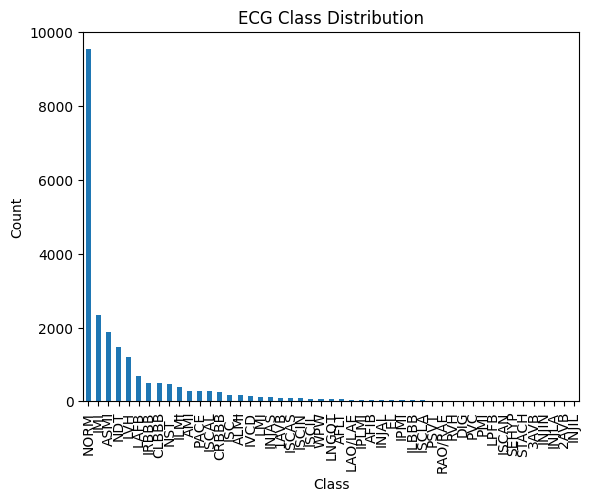

In [5]:
%pip install matplotlib
import matplotlib.pyplot as plt

label_counts = df['label'].value_counts()

print(label_counts)

# Plot distribution
plt.figure()
label_counts.plot(kind='bar')
plt.title("ECG Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
%pip install wfdb
import wfdb
from pathlib import Path

record_path = r"C:\LEARNING\MINOR_2\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.1\records100\00000\00001_lr.hea"

record_base = str(Path(record_path).with_suffix(''))

# rdsamp returns (signals, fields)
signals, fields = wfdb.rdsamp(record_base)

signal = signals  # ECG waveform

Note: you may need to restart the kernel to use updated packages.


In [7]:
print(signals.shape)

(1000, 12)


In [ ]:
if 'csv_path' in globals() and Path(csv_path).exists():
    df = pd.read_csv(csv_path)
elif 'base' in globals() and (base / "ptbxl_database.csv").exists():
    df = pd.read_csv(base / "ptbxl_database.csv")
else:
    candidates = list(Path(r"C:\LEARNING\MINOR_2").rglob("ptbxl_database.csv"))
    if candidates:
        df = pd.read_csv(candidates[0])
    else:
        raise FileNotFoundError("ptbxl_database.csv not found. Please verify the dataset path.")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (21837, 28)


,ecg_id,patient_id,age,sex,height,weight,nurse,site,device,recording_date,...,validated_by_human,baseline_drift,static_noise,burst_noise,electrodes_problems,extra_beats,pacemaker,strat_fold,filename_lr,filename_hr
0,1,15709.0,56.0,1,NaN,63.0,2.0,0.0,CS-12 E,1984-11-09 09:17:34,...,True,NaN,", I-V1,",NaN,NaN,NaN,NaN,3,records100/00000/00001_lr,records500/00000/00001_hr
1,2,13243.0,19.0,0,NaN,70.0,2.0,0.0,CS-12 E,1984-11-14 12:55:37,...,True,NaN,NaN,NaN,NaN,NaN,NaN,2,records100/00000/00002_lr,records500/00000/00002_hr
2,3,20372.0,37.0,1,NaN,69.0,2.0,0.0,CS-12 E,1984-11-15 12:49:10,...,True,NaN,NaN,NaN,NaN,NaN,NaN,5,records100/00000/00003_lr,records500/00000/00003_hr
3,4,17014.0,24.0,0,NaN,82.0,2.0,0.0,CS-12 E,1984-11-15 13:44:57,...,True,", II,III,AVF",NaN,NaN,NaN,NaN,NaN,3,records100/00000/00004_lr,records500/00000/00004_hr
4,5,17448.0,19.0,1,NaN,70.0,2.0,0.0,CS-12 E,1984-11-17 10:43:15,...,True,", III,AVR,AVF",NaN,NaN,NaN,NaN,NaN,4,records100/00000/00005_lr,records500/00000/00005_hr


In [ ]:
import ast
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)
df['label'] = df['scp_codes'].apply(lambda x: list(x.keys())[0])
df[['filename_lr', 'label']].head()

,filename_lr,label
0,records100/00000/00001_lr,NORM
1,records100/00000/00002_lr,NORM
2,records100/00000/00003_lr,NORM
3,records100/00000/00004_lr,NORM
4,records100/00000/00005_lr,NORM


In [10]:
df['binary_label'] = df['label'].apply(lambda x: 0 if x == 'NORM' else 1)

df['binary_label'].value_counts()

binary_label
1    12309
0     9528
Name: count, dtype: int64

In [ ]:
import numpy as np

signals = []
labels = []

sample_df = df.sample(500, random_state=42)
candidate_roots = []
if 'base' in globals():
    candidate_roots.append(base)
if 'csv_path' in globals():
    candidate_roots.append(Path(csv_path).parent)
if 'candidates' in globals() and candidates:
    candidate_roots.append(Path(candidates[0]).parent)

candidate_roots = list(dict.fromkeys(candidate_roots)) + [Path.cwd()]

for _, row in sample_df.iterrows():
    filename = Path(row['filename_lr'])
    found = False

    for root in candidate_roots:
        candidate = root / filename
        hea_file = candidate.with_suffix('.hea')
        if hea_file.exists():
            record_base = str(candidate)
            try:
                sig, _ = wfdb.rdsamp(record_base)
                signals.append(sig)
                labels.append(row['binary_label'])
                found = True
            except Exception as e:
                print(f"Failed to read {record_base}: {e}")
            break

    if not found:
        # skip missing records instead of raising; print helpful message
        print(f"Record not found for {filename}. Checked roots: {[str(r) for r in candidate_roots]} — skipping.")

if len(signals) == 0:
    raise FileNotFoundError("No records were found in any of the candidate locations. Verify dataset paths.")


X = np.stack(signals)
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (500, 1000, 12)
y shape: (500,)


In [12]:
pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout

model = Sequential([
    SimpleRNN(64, input_shape=(1000, 12)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

c:\LEARNING\PYTHON_START\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [14]:
model.fit(X, y, epochs=5, batch_size=16, validation_split=0.2)

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.5475 - loss: 0.6920 - val_accuracy: 0.5800 - val_loss: 0.6775
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.5450 - loss: 0.6993 - val_accuracy: 0.4300 - val_loss: 0.7355
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 112ms/step - accuracy: 0.5700 - loss: 0.6876 - val_accuracy: 0.4500 - val_loss: 0.7067
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.5550 - loss: 0.7022 - val_accuracy: 0.4200 - val_loss: 0.7040
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.5450 - loss: 0.6985 - val_accuracy: 0.6400 - val_loss: 0.6723


In [15]:
loss, acc = model.evaluate(X, y)
print("Accuracy:", acc)

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.5780 - loss: 0.6802
Accuracy: 0.578000009059906


Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.5700 - loss: 0.6807 - val_accuracy: 0.5500 - val_loss: 0.6868
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 99ms/step - accuracy: 0.5025 - loss: 0.7236 - val_accuracy: 0.5400 - val_loss: 0.6781
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - accuracy: 0.5200 - loss: 0.7207 - val_accuracy: 0.5900 - val_loss: 0.6754
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 86ms/step - accuracy: 0.4775 - loss: 0.7224 - val_accuracy: 0.6000 - val_loss: 0.6701
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.5650 - loss: 0.6799 - val_accuracy: 0.5800 - val_loss: 0.6642


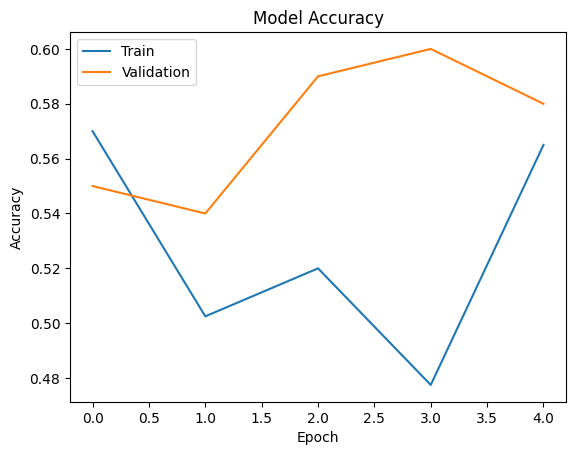

In [16]:
import matplotlib.pyplot as plt

history = model.fit(X, y, epochs=5, batch_size=16, validation_split=0.2)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

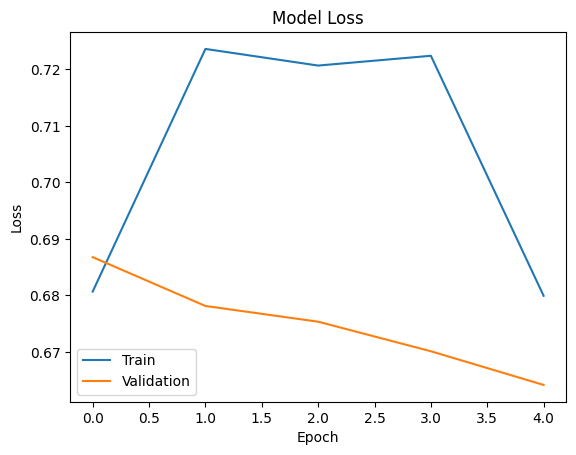

In [17]:
plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step


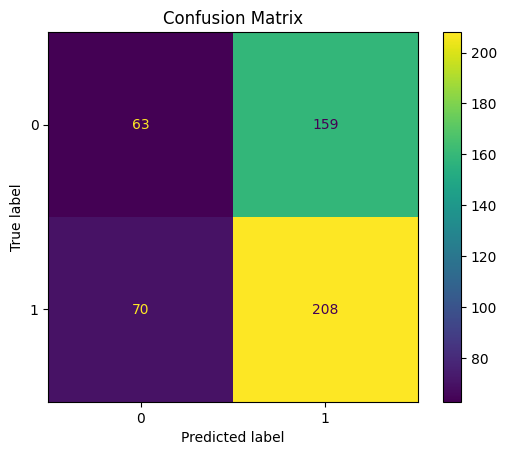

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Predictions
y_pred = (model.predict(X) > 0.5).astype(int)

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.47      0.28      0.35       222
           1       0.57      0.75      0.64       278

    accuracy                           0.54       500
   macro avg       0.52      0.52      0.50       500
weighted avg       0.53      0.54      0.52       500

